## 3. Implement your own KNN 

Check out exercise pikachu_pichu under the folder extra. This is quite good exercise to do to understand how KNN works and to learn how to work without libraries such as scikit-learn. I usually give out this exercise as a lab for the first python course for data science. 

The purpose of this exercise is to use the tools youʼve learned in Python to implement a simplified machine
learning algorithm.

In this lab there is (simulated) data for the heights and widths of Pichu and Pikachu. You will create an
algorithm that, based on the given data, can determine whether a new data point should be classified as
Pichu or Pikachu.

Note: You may not use data-processing libraries such as pandas or similar for this assignment. You
also may not use machine learning libraries. This lab is intended to give you practice with Python,
NumPy, and Matplotlib.

## Basic task

**Follow this flowchart to build the basic algorithm**

1. read data and store in appropriate data structure
2. plot all points with different classes in different colors
3. read and parse test points
4. compute distance between each test point and all other points
5. closest point is Pichu?
    - Yes?
        - classify as Pichu
    - No?
        - classify as Pikachu

### 1. read data and store in appropriate data structure

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

with open("pichu.txt", "r") as data:
    pichu = data.read().split("\n")
with open("pikachu.txt", "r") as data:
    pikachu = data.read().split("\n")
with open("test_points.txt", "r") as data:
    test_points = data.read()



pichu = pichu[1:]
pikachu = pikachu[1:]

def pokemon_dict(pokemon):
    width = []
    height = []
    for line in pokemon:
        if line.strip():
            w, h = line.strip("()").split(",")
            width.append(float(w))
            height.append(float(h))

    return {
        "width (cm)": width,
        "height (cm)": height 
    }
pika_dict = pokemon_dict(pikachu)
pichu_dict = pokemon_dict(pichu)

pokemons = {
    "Pikachu": pika_dict,
    "Pichu": pichu_dict
}
pokemons["Pichu"]["width (cm)"]

### 2. plot all points with different classes in different colors

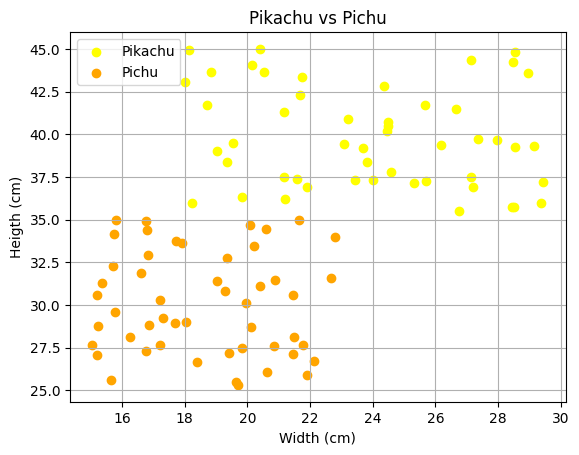

In [42]:
pikachu = pokemons["Pikachu"]
pichu = pokemons["Pichu"]

plt.scatter(pikachu["width (cm)"], pikachu["height (cm)"], color="yellow", label="Pikachu")
plt.scatter(pichu["width (cm)"], pichu["height (cm)"], color="orange", label="Pichu")

plt.xlabel("Width (cm)")
plt.ylabel("Heigth (cm)")
plt.title("Pikachu vs Pichu")
plt.legend()
plt.grid(True)
plt.show()

### 3. read and parse test points

In [48]:
points = test_points.replace(" ", "").split("),")

test_point_list = []
for point in points:
    point = point.strip("()")
    w, h = point.split(",")
    test_point_list.append((float(w), float(h)))

test_point_list

[(25.0, 35.0), (15.0, 14.0), (26.0, 30.0), (22.0, 45.0)]

### 4. compute distance between each test point and all other points
- euclidean distance
    - avstånd(fågelväg) = roten ur (x-x)^2+(y-y)^2
1. mät avstånd mellan test och all träningsdata
2. sort descending order
3. choose k nearest point

In [51]:
all_points = []
all_labels = []

for label, data in pokemons.items():
    widths = data["width (cm)"]
    heights = data["height (cm)"]
    for w, h in zip(widths, heights):
        all_points.append((w, h))
        all_labels.append(label)

all_points = np.array(all_points)
all_labels = np.array(all_labels)

for test_point in test_point_list:
    w_test, h_test = test_point
    distances = np.sqrt((all_points[:,0] - w_test)**2 + (all_points[:,1] - h_test)**2)
    closest_index = np.argmin(distances)
    classification = all_labels[closest_index]
    print(f"Sample with (width, height): {test_point} classified as {classification}")

Sample with (width, height): (25.0, 35.0) classified as Pikachu
Sample with (width, height): (15.0, 14.0) classified as Pichu
Sample with (width, height): (26.0, 30.0) classified as Pichu
Sample with (width, height): (22.0, 45.0) classified as Pikachu


**Answers for the given test data:**
- Sample with (width, height): (25, 35) classified as Pikachu 
- Sample with (width, height): (15, 14) classified as Pichu 
- Sample with (width, height): (26, 30) classified as Pichu 
- Sample with (width, height): (22, 45) classified as Pikachu 

## Tasks
**Do these tasks after you have correctly classified the test data.**

1. Let the user enter a test point and determine its class. Include error handling for negative numbers
and non-numeric inputs. Make sure the error messages are user-friendly.
2. The approach we used with the nearest point can misclassify when the points for the respective
classes overlap. Now, instead, choose the five nearest points to your test point. The class of the test
point is determined by the majority class among the nearest points.

**Majority voting:**

3.  Randomly split the original data so that:
    - 90 are training data (45 Pikachu, 45 Pichu)
    - 10 are test data (5 Pikachu, 5 Pichu)
4. Compute the accuracy using the following formula
    - accuracy = #TP+#TN / Total

where:
| prediction | Pikachu actual | Pichu actual |
| ---------- | -------------- | ------------ |
| Pikachu predicted |      TP             | FP |
| Pichu predicted |        FN             | TN |

Here we treat Pikachu as positive and Pichu as “non-Pikachu,” i.e., negative.
Also compute recall and precision.

### 1. Let the user enter a test point and determine its class. Include error handling for negative numbers and non-numeric inputs. Make sure the error messages are user-friendly.

In [52]:
while True:
    user_input = input("Enter test point as 'width,height' (or 'quit' to exit): ")
    if user_input.lower() == "quit":
        break

    try:
        width_str, height_str = user_input.split(",")
        width = float(width_str)
        height = float(height_str)

        # Check for negative values
        if width < 0 or height < 0:
            print("Error: Width and height must be positive numbers. Please try again.\n")
            continue

        # Compute distances to all training points
        distances = np.sqrt((all_points[:,0] - width)**2 + (all_points[:,1] - height)**2)
        closest_index = np.argmin(distances)
        classification = all_labels[closest_index]

        print(f"The test point ({width}, {height}) is classified as {classification}.\n")

    except ValueError:
        print("Error: Please enter two numbers separated by a comma, e.g., 25,35.\n")


The test point (25.0, 35.0) is classified as Pikachu.



### 2. The approach we used with the nearest point can misclassify when the points for the respective classes overlap. Now, instead, choose the five nearest points to your test point. The class of the test point is determined by the majority class among the nearest points.

In [54]:
def knn(dataset, test_points, k):
    all_points = []
    all_labels = []
    for label, data in dataset.items():
        widths = data["width (cm)"]
        heights = data["height (cm)"]
        for w, h in zip(widths, heights):
            all_points.append((w, h))
            all_labels.append(label)
        
    for test_point in test_points:
        w_test, h_test = test_point
        # Compute distances to all training points
        distances = np.sqrt((all_points[:,0] - w_test)**2 + (all_points[:,1] - h_test)**2)
        # Get indices of the 5 nearest neighbors
        nearest_indices = np.argsort(distances)[:k]
        # Get the labels of these neighbors
        nearest_labels = all_labels[nearest_indices]
        # Determine the majority class
        counts = {}
        for label in nearest_labels:
            counts[label] = counts.get(label, 0) + 1
        majority_class = max(counts, key=counts.get)
        print(f"Test point {test_point} is classified as {majority_class} using 5-NN")



In [56]:
k = 5  # number of nearest neighbors

for test_point in test_point_list:
    w_test, h_test = test_point

    # Compute distances to all training points
    distances = np.sqrt((all_points[:,0] - w_test)**2 + (all_points[:,1] - h_test)**2)

    # Get indices of the 5 nearest neighbors
    nearest_indices = np.argsort(distances)[:k]

    # Get the labels of these neighbors
    nearest_labels = all_labels[nearest_indices]

    # Determine the majority class
    counts = {}
    for label in nearest_labels:
        counts[label] = counts.get(label, 0) + 1
    majority_class = max(counts, key=counts.get)

    print(f"Test point {test_point} is classified as {majority_class} using 5-NN")

Test point (25.0, 35.0) is classified as Pikachu using 5-NN
Test point (15.0, 14.0) is classified as Pichu using 5-NN
Test point (26.0, 30.0) is classified as Pichu using 5-NN
Test point (22.0, 45.0) is classified as Pikachu using 5-NN


### 3.  Randomly split the original data so that:
            - 90 are training data (45 Pikachu, 45 Pichu)
            - 10 are test data (5 Pikachu, 5 Pichu)

In [57]:
import random

# Function to split data into training and test sets
def split_data(pokemon_dict, train_size, test_size):
    data = list(zip(pokemon_dict["width (cm)"], pokemon_dict["height (cm)"]))
    random.shuffle(data)
    train_data = data[:train_size]
    test_data = data[train_size:train_size+test_size]
    return train_data, test_data

# Set random seed for reproducibility
random.seed(42)

# Split Pikachu and Pichu data
pikachu_train, pikachu_test = split_data(pokemons["Pikachu"], train_size=45, test_size=5)
pichu_train, pichu_test = split_data(pokemons["Pichu"], train_size=45, test_size=5)

# Combine training and test sets
train_data = pikachu_train + pichu_train
train_labels = ["Pikachu"]*45 + ["Pichu"]*45

test_data = pikachu_test + pichu_test
test_labels = ["Pikachu"]*5 + ["Pichu"]*5

# Optional: convert to NumPy arrays for easier computation
train_data = np.array(train_data)
train_labels = np.array(train_labels)
test_data = np.array(test_data)
test_labels = np.array(test_labels)

# Check shapes
print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Training data shape: (90, 2)
Test data shape: (10, 2)


### 4. Compute the accuracy using the following formula
    - accuracy = #TP+#TN / Total

In [59]:
k = 5

# Initialize counts
TP = TN = FP = FN = 0

for i, test_point in enumerate(test_data):
    w_test, h_test = test_point

    # Compute distances to all training points
    distances = np.sqrt((train_data[:,0] - w_test)**2 + (train_data[:,1] - h_test)**2)

    # Find k nearest neighbors
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = train_labels[nearest_indices]

    # Majority vote
    counts = {}
    for label in nearest_labels:
        counts[label] = counts.get(label, 0) + 1
    predicted_class = max(counts, key=counts.get)

    # True label
    true_class = test_labels[i]

    # Update TP, TN, FP, FN (Pikachu = positive)
    if predicted_class == "Pikachu":
        if true_class == "Pikachu":
            TP += 1
        else:
            FP += 1
    else:  # predicted Pichu
        if true_class == "Pichu":
            TN += 1
        else:
            FN += 1

# Compute metrics
accuracy = (TP + TN) / len(test_data)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

Accuracy: 100.00%
Recall: 100.00%
Precision: 100.00%
TP=5, TN=5, FP=0, FN=0


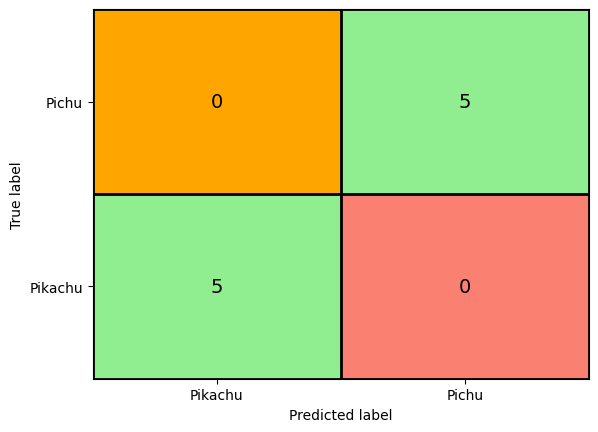

In [62]:
cm = [[TP, FP],
      [FN, TN]]

classes = ["Pikachu", "Pichu"]

# Define colors for each cell: TP=green, TN=green, FP=red, FN=orange
colors = [["lightgreen", "salmon"],
          ["orange", "lightgreen"]]

fig, ax = plt.subplots()
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colors[i][j]))
        ax.text(j + 0.5, i + 0.5, cm[i][j], ha="center", va="center", fontsize=14)

# Set limits and labels
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# Remove grid lines
ax.set_xticks([0,1,2], minor=True)
ax.set_yticks([0,1,2], minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
ax.tick_params(which="minor", length=0)

plt.show()